In [15]:
import rebound
from rfc_prototype import FeatureClassifier
import numpy as np
import matplotlib.pyplot as plt
#import os

## Common `rebound.Simulation.add()` Parameters

When adding particles to a `rebound` simulation, several parameters can be used to define their orbital elements and properties. Here's a summary of the most common ones:

*   **`primary`**
    *   **Definition:** The central body object or particle index that this orbit reference frame circles (defaults to the first added particle, `sim.particles[0]`).

*   **`m` (mass)**
    *   **Definition:** The mass of the particle.
    *   **Units:** Solar masses ($M_\odot$) by default, unless `rebound.constants.G` is changed. For convenience, when dealing with planets, often Earth masses or Jupiter masses are converted to solar masses.
    *   **Range:** Any non-negative float. $m > 0$ for massive particles, $m = 0$ for test particles.

*   **`P` (orbital period)**
    *   **Definition:** The orbital period of the particle around its central body (or the barycenter).
    *   **Units:** Years, by default (or the chosen time unit for your simulation, consistent with the `G` constant).
    *   **Range:** Any positive float.

*   **`a` (semimajor axis)**
    *   **Definition:** The semimajor axis of the particle's orbit.
    *   **Units:** Astronomical Units (AU), by default (or consistent with your chosen distance unit).
    *   **Range:** Any positive float.

*   **`e` (eccentricity)**
    *   **Definition:** The eccentricity of the orbit, which describes its shape (0 for circular, <1 for elliptical, 1 for parabolic, >1 for hyperbolic).
    *   **Units:** Dimensionless.
    *   **Range:** `0 <= e < 1` for bound, elliptical orbits. (Can be 1 or >1 for unbound orbits, but typically used for bound systems).

*   **`inc` (inclination)**
    *   **Definition:** The inclination of the orbit with respect to the reference plane.
    *   **Units:** Radians. (Can often be specified in degrees and converted using `numpy.radians()` or `math.radians()`).
    *   **Range:** `0 <= inc <= pi` (0 to 180 degrees).

*   **`Omega` (longitude of ascending node)**
    *   **Definition:** The longitude of the ascending node, which is the angle from the x-axis to the ascending node (where the orbit crosses the reference plane from south to north).
    *   **Units:** Radians.
    *   **Range:** `0 <= Omega < 2*pi` (0 to 360 degrees).

*   **`omega` (argument of pericenter)**
    *   **Definition:** The argument of pericenter (or periastron for stars, perihelion for Sun), which is the angle from the ascending node to the pericenter (point of closest approach).
    *   **Units:** Radians.
    *   **Range:** `0 <= omega < 2*pi` (0 to 360 degrees).

*   **`pomega` (longitude of pericenter)**
    *   **Definition:** The longitude of pericenter, defined as `pomega = Omega + omega`. It's the angle from the x-axis to the pericenter.
    *   **Units:** Radians.
    *   **Range:** `0 <= pomega < 2*pi` (0 to 360 degrees).

*   **`f` (true anomaly)**
    *   **Definition:** The true anomaly, which is the angle from the pericenter to the current position of the particle, measured along the orbit.
    *   **Units:** Radians.
    *   **Range:** `0 <= f < 2*pi` (0 to 360 degrees).

*   **`M` (mean anomaly)**
    *   **Definition:** The mean anomaly, a fictitious angle that increases uniformly with time from the pericenter, used to simplify calculations of orbital position.
    *   **Units:** Radians.
    *   **Range:** `0 <= M < 2*pi` (0 to 360 degrees).

*   **`l` (mean longitude)**
    *   **Definition:** The mean longitude, defined as `l = Omega + omega + M`. It's the angle from the x-axis to the mean position of the particle.
    *   **Units:** Radians.
    *   **Range:** `0 <= l < 2*pi` (0 to 360 degrees).

**Note on units:** `rebound` uses a self-consistent set of units. By default, if `G=1`, masses are in solar masses, distances in AU, and time in years. If you change `G` to a different value (e.g., `rebound.constants.G_cgs` for cgs units), all other units will adapt accordingly to maintain consistency.

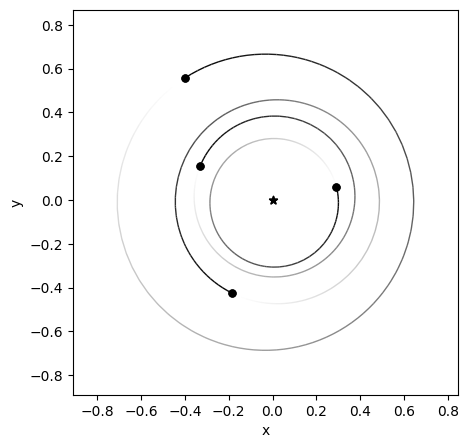

In [42]:
sim = rebound.Simulation()
sim.add(m=1.)
sim.add(m=3.e-5, P=1., e=0.05, pomega = 2.1, l=0.3)
sim.add(m=3.e-5, P=1.4, e=0.05, pomega = 4.2, l=2.8)
sim.add(m=3.e-5, P=2, e=0.05, pomega = 2.8, l=4.2)
sim.add(m=3.e-5, P=3.5, e=0.05, pomega = 0.3, l=2.1)
sim.move_to_com()
fig = rebound.OrbitPlot(sim)

# Binary Star System:
---

In [37]:
M_A = 1.133 # mass of star A in solar masses
M_B = 0.972 # mass of star B in solar masses
mu = M_B / (M_A + M_B) # the binary mass ratio
a_bin = 23.78 # semimajor axis in AU
e_bin = 0.524 # eccentricity
omg_bin = np.radians(77.05) # pericenter of binary converted to radians
MA_bin = np.radians(209.6901) # mean anomaly of binary @ JD 2452276
T_bin = np.sqrt(a_bin**3/(M_A+M_B)) # period of the binary in years (~79.9 years)

M_pl_1 = 3.0035e-6 #mass of Earth in solar masses
a_pl_1 = 2. # semimajor axis in AU

M_pl_2 = 2 * M_pl_1 # twice the mass of Earth in solar masses
a_pl_2 = 3. # semimajor axis in AU

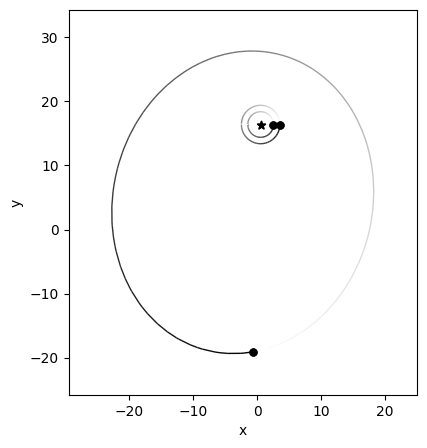

In [41]:
sim = rebound.Simulation()

sim.add(m=M_A) # Primary Star
sim.add(m=M_pl_1,a=a_pl_1, M=0) # Planet 1
sim.add(m=M_pl_2,a=a_pl_2) # Planet 2
sim.add(m=M_B,a=a_bin,e=e_bin,omega=omg_bin,M=MA_bin) # Secondary Star (i=Omega=0 by default)
sim.move_to_com()  # convert to center of mass coordinates

fig = rebound.OrbitPlot(sim)

In [ ]:
feature_model = FeatureClassifier()

print(feature_model.predict_stable(sim, mu, e_bin))